# Machine Learning on Embeddings for Epitope Prediction

The goal of this notebook is to put together a basic machine learning pipeline that can make epitope predictions using embeddings from AF3 and ESM

## Environment:

This notebook will run with the 'envs/env.yaml` environment (epident-experiments)

## Bepipred 3 dataset

- job_name: unique identifier for protein, comes from hash of seq
- seq: amino acid sequence of protein
- train: boolean indicating if seq is part of train set
- epitope_boolmask: boolean array the same length as seq indiciating if the AA at that position is an epitope residue
- raw_protein_id: original ID assigned to protein in BP3C50ID set
- RSA: relative solvent accessiblity of the protein at each AA, calculated by FreeSASA
- SA: absolute solvent accessibility of the protein at each AA, calculated by FreeSASA

In [48]:
# --- Imports ---

import polars as pl
import pandas as pd
import pickle
from mdaf3.AF3OutputParser import AF3Output
from pathlib import Path
import torch
import numpy as np
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler  
from sklearn.metrics import roc_auc_score
from plotnine import *
theme_set(theme_classic())

# --- Bepipred3 Data ---

bp3 = pl.read_parquet("../data/bp3c50id/bp3c50id.rsa.parquet")
bp3 = bp3.rename({"test" : "train"})
print(bp3)

shape: (358, 7)
┌───────────────┬──────────────┬───────┬──────────────┬──────────────┬──────────────┬──────────────┐
│ job_name      ┆ seq          ┆ train ┆ epitope_bool ┆ raw_protein_ ┆ RSA          ┆ SA           │
│ ---           ┆ ---          ┆ ---   ┆ mask         ┆ id           ┆ ---          ┆ ---          │
│ str           ┆ str          ┆ bool  ┆ ---          ┆ ---          ┆ list[f64]    ┆ list[f64]    │
│               ┆              ┆       ┆ list[bool]   ┆ str          ┆              ┆              │
╞═══════════════╪══════════════╪═══════╪══════════════╪══════════════╪══════════════╪══════════════╡
│ bf2a62534941c ┆ LIQTPSSLLVQT ┆ true  ┆ [false,      ┆ 3b9k_B       ┆ [0.205823,   ┆ [36.957627,  │
│ f895971e1daa3 ┆ NHTAKMSCEVKS ┆       ┆ false, …     ┆              ┆ 0.471213, …  ┆ 82.806331, … │
│ 3a46…         ┆ ISKLTS…      ┆       ┆ false]       ┆              ┆ 1.00154…     ┆ 152.2…       │
│ d4febd28417e8 ┆ GNVDLVFLFDGS ┆ true  ┆ [false,      ┆ 3hi6_A       ┆ [0.8

## Getting structural embeddings for a protein


In [2]:
# --- AF3 Embeddings ---

INF_DIR = Path("../data/bp3c50id/inference")
sample_job_name = bp3.select("job_name")[0].item()
af3_output = AF3Output(INF_DIR / sample_job_name)

af3_single_embed = af3_output.get_single_embeddings()
af3_pairwise_embed = af3_output.get_pair_embeddings()

#af3_single_embed
#af3_pairwise_embed

## Getting LM embeddings for a protein


In [3]:
# --- ESM Embeddings ---

ESM_ENCODING_DIR = Path("/tgen_labs/altin/esm_encodings")
esm_2_embed = torch.load(ESM_ENCODING_DIR / (sample_job_name + ".pt")).tolist()

if "esm_emb" not in bp3.columns:
    esm_embeddings = []
    for job_num in range(bp3.shape[0]):
        job_name = bp3.select("job_name")[job_num].item()
        esm_embeddings.append(torch.load(ESM_ENCODING_DIR / (job_name + ".pt")))
    esm_emb = pl.Series("esm_emb", esm_embeddings)
    bp3.insert_column(0, esm_emb)
    bp3 = bp3.drop(['job_name', "raw_protein_id", 'SA'])

if "train_boolmask" not in bp3:
    train_boolmask = []
    for (esm_emb, seq, train, epitope_boolmask, rsa) in bp3.iter_rows():
        train_bools = []
        for num in range(len(seq)):
            train_bools.append(train)
        train_boolmask.append(train_bools)
    train_boolmask = pl.Series("train_boolmask", train_boolmask)
    bp3.insert_column(2, train_boolmask)
    bp3 = bp3.drop(['train'])
    
print(bp3)


shape: (358, 5)
┌─────────────────────┬────────────────────┬────────────────────┬────────────────────┬─────────────┐
│ esm_emb             ┆ seq                ┆ train_boolmask     ┆ epitope_boolmask   ┆ RSA         │
│ ---                 ┆ ---                ┆ ---                ┆ ---                ┆ ---         │
│ object              ┆ str                ┆ list[bool]         ┆ list[bool]         ┆ list[f64]   │
╞═════════════════════╪════════════════════╪════════════════════╪════════════════════╪═════════════╡
│ tensor([[-7.9217e-0 ┆ LIQTPSSLLVQTNHTAKM ┆ [true, true, …     ┆ [false, false, …   ┆ [0.205823,  │
│ 2, -8.2230e…        ┆ SCEVKSISKLTS…      ┆ true]              ┆ false]             ┆ 0.471213, … │
│                     ┆                    ┆                    ┆                    ┆ 1.00154…    │
│ tensor([[           ┆ GNVDLVFLFDGSMSLQPD ┆ [true, true, …     ┆ [false, false, …   ┆ [0.840245,  │
│ 2.8654e-01,         ┆ EFQKILDFMKDV…      ┆ true]              ┆ false]   

In [4]:
# --- Transform to Per-Residue Basis ---
 
embs = []
residues = []
train_bools = []
epitope_bools = []
rsa_vals = []
for (esm_emb, seq, train_boolmask, epitope_boolmask, rsa) in bp3.iter_rows():
    embs.extend(esm_emb.tolist())
    residues.extend(seq)
    train_bools.extend(train_boolmask)
    epitope_bools.extend(epitope_boolmask)
    rsa_vals.extend(rsa)

data = {
    "embeddings" : embs,
    "residues" : residues,
    "train_bools" : train_bools,
    "epitope_bools" : epitope_bools,
    "rsa_vals" : rsa_vals
}

bp3_res = pl.DataFrame(data).with_row_index()
bp3_res


index,embeddings,residues,train_bools,epitope_bools,rsa_vals
u32,list[f64],str,bool,bool,f64
0,"[-0.079217, -0.08223, … 117.0]","""L""",true,false,0.205823
1,"[0.271906, 0.131599, … 117.0]","""I""",true,false,0.471213
2,"[0.075211, -0.124738, … 117.0]","""Q""",true,false,0.046812
3,"[0.033206, 0.13658, … 117.0]","""T""",true,false,0.437416
4,"[-0.153488, 0.178101, … 117.0]","""P""",true,false,0.312792
…,…,…,…,…,…
84434,"[-0.102616, 0.023357, … 47.0]","""V""",false,false,0.09529
84435,"[0.006365, -0.054578, … 47.0]","""Q""",false,false,0.559269
84436,"[-0.021138, 0.060409, … 47.0]","""K""",false,false,0.883928


In [5]:
var_list = []
for var in range(len(bp3_res.select("embeddings")[0].item().to_list())):
    var_list.append("var" + str(var))

var_names = []
for var in range(bp3_res.height):
    var_names.append(var_list)


In [23]:
bp3_res

index,field_0,field_1,field_2,field_3,field_4,field_5,field_6,field_7,field_8,field_9,field_10,field_11,field_12,field_13,field_14,field_15,field_16,field_17,field_18,field_19,field_20,field_21,field_22,field_23,field_24,field_25,field_26,field_27,field_28,field_29,field_30,field_31,field_32,field_33,field_34,field_35,…,field_1248,field_1249,field_1250,field_1251,field_1252,field_1253,field_1254,field_1255,field_1256,field_1257,field_1258,field_1259,field_1260,field_1261,field_1262,field_1263,field_1264,field_1265,field_1266,field_1267,field_1268,field_1269,field_1270,field_1271,field_1272,field_1273,field_1274,field_1275,field_1276,field_1277,field_1278,field_1279,field_1280,residues,train_bools,epitope_bools,rsa_vals
u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,bool,bool,f64
0,-0.079217,-0.08223,0.05838,-0.014281,-0.174122,-0.079725,0.311082,0.159403,-0.060938,0.090724,0.111589,0.261834,0.024881,0.198776,0.018271,0.11828,0.482811,0.244908,0.290209,0.064428,-0.258763,0.022362,0.1669,0.373052,0.144847,-0.003963,-0.059578,0.005104,0.085477,0.140755,0.016558,0.155509,-0.346879,0.351254,0.065172,0.068091,…,-0.06339,0.166055,-0.135506,0.020469,-0.046917,0.264124,0.108552,-0.16462,0.083087,0.034967,-0.066435,0.118048,-0.23741,-0.019455,-0.029853,0.106312,0.154892,-0.109844,0.137809,-0.054536,0.320051,0.080654,-0.236098,-0.390364,-0.207083,-0.028872,0.133424,0.46441,0.105135,-0.035788,0.246807,0.096495,117.0,"""L""",true,false,0.205823
1,0.271906,0.131599,-0.127488,0.218813,-0.318881,-0.32619,0.283068,0.242302,-0.119848,-0.171026,0.360055,0.048574,0.051404,-0.120529,0.077561,-0.30966,0.494973,0.246852,0.169573,-0.065812,0.102363,-0.020451,0.131842,-0.128308,0.276413,0.028705,-0.048571,-0.099105,-0.303759,-0.038712,0.007854,0.247406,-0.098611,-0.053378,-0.306477,-0.241984,…,0.05328,0.227172,-0.123788,0.589519,0.081992,0.123722,0.122775,0.04476,0.020768,-0.143507,-0.011657,0.201338,-0.062858,0.083641,0.104042,-0.109236,0.13792,-0.031377,0.134023,-0.080985,0.233233,0.142581,0.050323,0.062281,-0.155307,0.170265,0.012759,0.184251,0.210409,-0.066236,0.083813,0.026999,117.0,"""I""",true,false,0.471213
2,0.075211,-0.124738,-0.312846,0.224769,0.048075,-0.412029,0.633058,0.185147,-0.160633,0.34018,0.129026,0.19204,0.383036,-0.413261,0.087679,-0.442805,0.165223,0.138972,0.010817,0.066011,0.03172,0.015374,-0.154199,0.069085,-0.074526,0.342112,0.755198,-0.039584,0.10898,0.26805,-0.161822,-0.093352,0.09156,0.440921,0.022243,-0.135373,…,-0.122256,0.535823,-0.299245,0.057628,0.085683,0.471125,0.272395,0.040267,-0.290351,-0.330009,0.061787,0.039009,-0.136231,0.390063,0.081705,0.407417,0.082421,0.109496,-0.500798,-0.371928,0.210499,0.054817,-0.037059,-0.100564,-0.172441,-0.105397,-0.115531,0.156894,-0.043453,-0.367025,-0.070912,-0.130206,117.0,"""Q""",true,false,0.046812
3,0.033206,0.13658,0.029649,0.115601,0.080504,0.20587,0.174843,0.08255,0.236684,0.409561,0.445139,-0.043016,0.395532,-0.280186,0.365009,-0.288693,0.028138,-0.008878,0.179828,0.069011,-0.096423,-0.183503,0.027735,0.186893,0.022349,-0.217998,-0.129381,-0.103567,0.090453,-0.170609,-0.146867,0.205691,0.064341,0.008259,-0.114886,0.089,…,-0.227127,0.322171,-0.075757,0.385428,-0.169671,0.104973,-0.01161,-0.059359,0.2851,-0.235702,-0.050277,0.098363,-0.079774,0.229683,0.108128,-0.089006,-0.140968,-0.207516,-0.022658,-0.127732,0.038616,0.009931,0.187821,-0.034119,-0.089407,-0.252221,-0.086275,0.200142,0.0247,0.14825,-0.084408,-0.163228,117.0,"""T""",true,false,0.437416
4,-0.153488,0.178101,0.076767,0.277805,-0.062598,-0.01716,0.25421,0.138347,-0.016413,0.144155,0.262325,0.239095,0.683909,-0.260452,0.162966,0.116701,0.409806,-0.16385,-0.095509,0.39366,-0.202302,-0.118709,-0.203511,0.071376,-0.020334,-0.241092,0.009244,-0.014142,-0.097118,-0.131135,-0.103788

In [15]:
bp3_res = bp3_res.with_columns(
    pl.col("embeddings").list.to_struct(upper_bound=1281)
).unnest("embeddings")

In [ ]:
#with open('bp3_res.pkl', 'wb') as f:
#        pickle.dump(bp3_res, f)
#
#with open("bp3_res.pkl", 'rb') as f:
#        bp3_res = pickle.load(f)

In [ ]:
# --- Extract N Most Informative Features of Embedding ---

num_emb_vars = bp3_res.select("embeddings")[0].item().shape[0]

u_vals = []
p_vals = []
for var in range(num_emb_vars):
    var_epi = []
    var_nepi = []
    for (embedding, residue, train_bool, epitope_bool, rsa) in bp3_res.iter_rows():
        if epitope_bool == True:
            var_epi.append(embedding[var])
        else:
            var_nepi.append(embedding[var])
    u, p = stats.mannwhitneyu(var_epi, var_nepi, alternative="two-sided")
    u_vals.append(u)
    p_vals.append(p)



In [26]:
with open("best_esm_embedding_vars.pkl", 'rb') as file:
        # Load the pickled data from the file
        p_vals = pickle.load(file)

In [27]:
print(p_vals)

[(np.float64(81.0), 1280), (np.float64(1.130703330039978), 234), (np.float64(0.3712773323059082), 1160), (np.float64(0.045004742220044136), 839), (np.float64(0.044218819588422775), 553), (np.float64(0.04032979533076286), 696), (np.float64(0.03747392725199461), 414), (np.float64(0.03660698514431715), 1251), (np.float64(0.03643316403031349), 600), (np.float64(0.0351506844162941), 381), (np.float64(0.034491033758968115), 756), (np.float64(0.033380577340722084), 300), (np.float64(0.03337776567786932), 1014), (np.float64(0.03284870833158493), 1186), (np.float64(0.03240643069148064), 855), (np.float64(0.032072730362415314), 608), (np.float64(0.031966139416908845), 86), (np.float64(0.031056914827786386), 396), (np.float64(0.030288565903902054), 655), (np.float64(0.030203919857740402), 166), (np.float64(0.030178461922332644), 423), (np.float64(0.029451459646224976), 809), (np.float64(0.028364425525069237), 77), (np.float64(0.02815424744039774), 249), (np.float64(0.028020352125167847), 145), (n

In [5]:
print(len(p_vals))
indexed_list = [(value, index) for index, value in enumerate(p_vals)]
sorted_indexed_list = sorted(indexed_list, key=lambda x: x[0], reverse=False)
print(sorted_indexed_list)

#with open('best_embedding_vars_whitney2.pkl', 'wb') as f:
#        pickle.dump(sorted_indexed_list, f)

NameError: name 'p_vals' is not defined

In [ ]:
emb_1280 = []
emb_1279 = []
emb_1278 = []
emb_1277 = []
emb_1276 = []
emb_1275 = []
emb_1274 = []
emb_1273 = []
emb_1272 = []
emb_1271 = []
for (idx, embedding, residue, train_bool, epitope_bool, rsa) in bp3_res.iter_rows():
    emb_1280.append(embedding[1280])
    emb_1279.append(embedding[1279])
    emb_1278.append(embedding[1278])
    emb_1277.append(embedding[1277])
    emb_1276.append(embedding[1276])
    emb_1275.append(embedding[1275])
    emb_1274.append(embedding[1274])
    emb_1273.append(embedding[1273])
    emb_1272.append(embedding[1272])
    emb_1271.append(embedding[1271])

bp3_res.insert_column(0, pl.Series("emb_1280", emb_1280))
bp3_res.insert_column(0, pl.Series("emb_1279", emb_1279))
bp3_res.insert_column(0, pl.Series("emb_1278", emb_1278))
bp3_res.insert_column(0, pl.Series("emb_1277", emb_1277))
bp3_res.insert_column(0, pl.Series("emb_1276", emb_1276))
bp3_res.insert_column(0, pl.Series("emb_1275", emb_1275))
bp3_res.insert_column(0, pl.Series("emb_1274", emb_1274))
bp3_res.insert_column(0, pl.Series("emb_1273", emb_1273))
bp3_res.insert_column(0, pl.Series("emb_1272", emb_1272))
bp3_res.insert_column(0, pl.Series("emb_1271", emb_1271))


emb_1271,emb_1272,emb_1273,emb_1274,emb_1275,emb_1276,emb_1277,emb_1278,emb_1279,emb_1280,embeddings,residues,train_bools,epitope_bools,rsa_vals
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[f64],str,bool,bool,f64
-0.390364,-0.207083,-0.028872,0.133424,0.46441,0.105135,-0.035788,0.246807,0.096495,117.0,"[-0.079217, -0.08223, … 117.0]","""L""",true,false,0.205823
0.062281,-0.155307,0.170265,0.012759,0.184251,0.210409,-0.066236,0.083813,0.026999,117.0,"[0.271906, 0.131599, … 117.0]","""I""",true,false,0.471213
-0.100564,-0.172441,-0.105397,-0.115531,0.156894,-0.043453,-0.367025,-0.070912,-0.130206,117.0,"[0.075211, -0.124738, … 117.0]","""Q""",true,false,0.046812
-0.034119,-0.089407,-0.252221,-0.086275,0.200142,0.0247,0.14825,-0.084408,-0.163228,117.0,"[0.033206, 0.13658, … 117.0]","""T""",true,false,0.437416
0.046669,-0.072711,-0.144304,-0.024676,0.258558,0.335825,-0.084774,0.045589,0.106432,117.0,"[-0.153488, 0.178101, … 117.0]","""P""",true,false,0.312792
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
-0.121133,0.105609,-0.02385,0.104386,0.041719,0.245388,-0.067179,-0.123521,0.203938,47.0,"[-0.102616, 0.023357, … 47.0]","""V""",false,false,0.09529
0.01941,0.025256,-0.039905,-0.044991,0.1173,0.097847,-0.062373,-0.110587,0.093242,47.0,"[0.006365, -0.054578, … 47.0]","""Q""",false,false,0.559269
-0.149773,-0.019055,-0.068777,0.16741,-0.255831,0.133178,-0.049465,-0.139063,0.120689,47.0,"[-0.021138, 0.060409, … 47.0]","""K""",false,false,0.883928


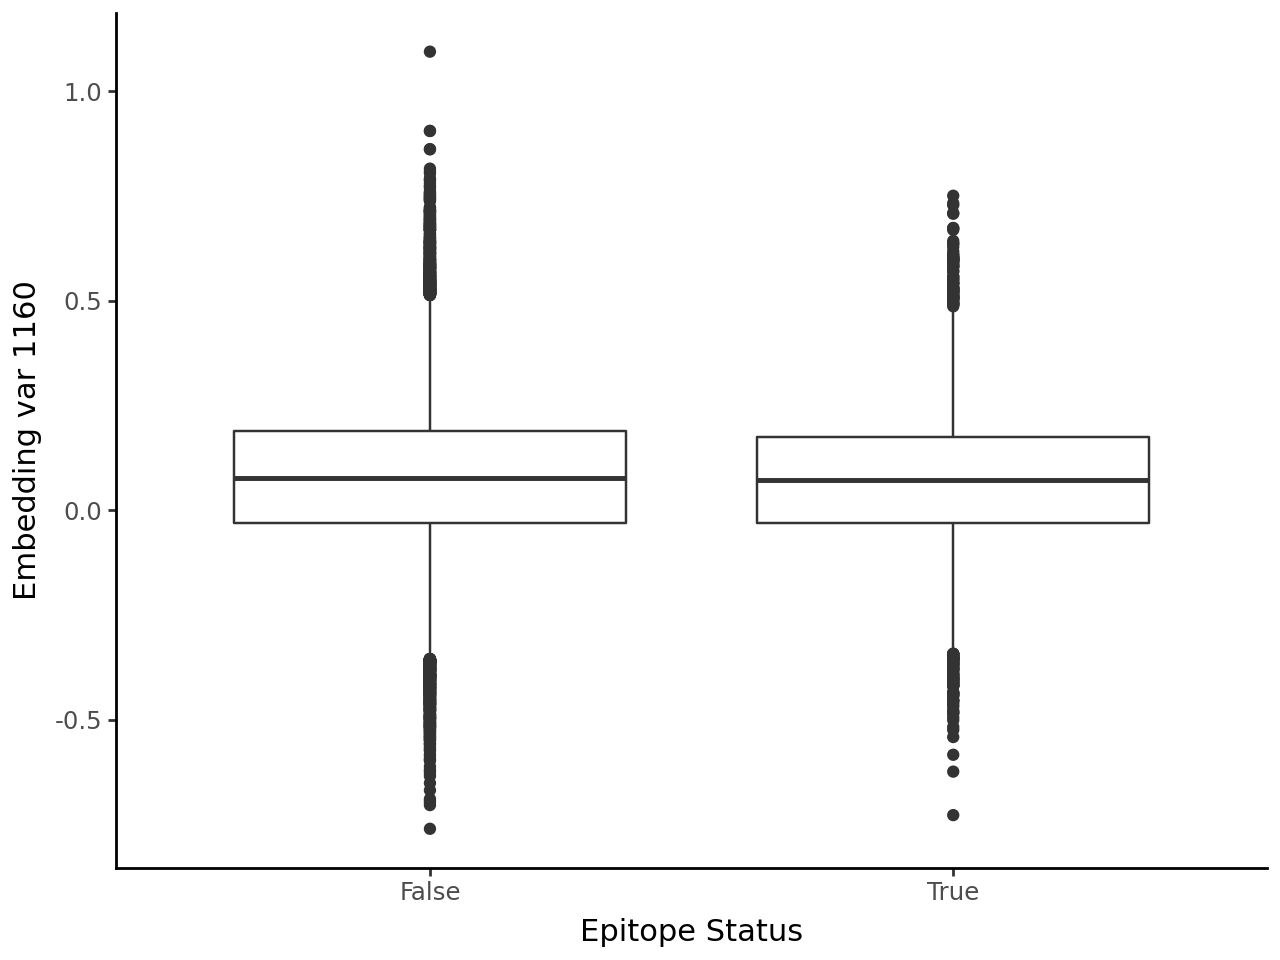

In [42]:
(
ggplot(bp3_res, aes(x = epitope_bools, y = emb_1276))
+ geom_boxplot()
+ labs(
    x = "Epitope Status",
    y = "Embedding var 1160"
)
#+ geom_jitter()
)

In [ ]:
# --- BP3 CV Evaluation ---

agg_features = []
for emb in range(1281):
    field = "field_" + str(emb)
    agg_features.append(field)
agg_features.append("rsa_vals")

train_df = bp3_res.to_pandas()
X_df = train_df[agg_features]
y_df = train_df["epitope_bools"]

X = X_df.values
y = y_df.values

n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=1)

train_auc_scores = []
test_auc_scores = []


print("--- Cross-Validation Fold Details ---")
for fold, (train_index, test_index) in enumerate(cv.split(X, y)):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # --- Scale Features ---
    scaler = StandardScaler()  
    scaler.fit(X_train)  
    X_train = scaler.transform(X_train)  
    X_test = scaler.transform(X_test)  

    # --- Choose Classifier ---
    neg_count = (y_train == 0).sum()
    pos_count = (y_train == 1).sum()
    scale_pos_weight_value = neg_count / pos_count if pos_count > 0 else 1

    #clf = RandomForestClassifier(class_weight="balanced")
    #clf = LogisticRegression(class_weight="balanced", penalty="l2", max_iter=10000, n_jobs=-1)
    clf = MLPClassifier(alpha=5)
    clf.fit(X_train, y_train)

    # --- Training AUC Calculation ---
    y_train_proba = clf.predict_proba(X_train)[:, 1]
    train_auc = roc_auc_score(y_train, y_train_proba)
    train_auc_scores.append(train_auc)

    # --- Test AUC Calculation ---
    y_test_proba = clf.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_test_proba)
    test_auc_scores.append(test_auc)

    print(f"Fold {fold+1}: Train AUC = {train_auc:.4f}, Test AUC = {test_auc:.4f}")

# Mean ROC data
mean_auc_test = np.mean(test_auc_scores)
std_auc_test = np.std(test_auc_scores)

# --- Overfitting Check Section ---
print("\n--- Overfitting Check ---")
mean_train_auc = np.mean(train_auc_scores)
std_train_auc = np.std(train_auc_scores)

print(
    f"Average Training AUC across folds: {mean_train_auc:.4f} (+/- {std_train_auc:.4f})"
)
print(
    f"Average Test (Validation) AUC across folds: {mean_auc_test:.4f} (+/- {std_auc_test:.4f})"
)

--- Cross-Validation Fold Details ---
